# Task 3: Exploratory Data Analysis (EDA) & Feature Engineering

## Objective
This notebook provides a comprehensive exploratory data analysis and feature engineering pipeline. We will:

### 1. **Data Understanding & Quality Assessment**
   - Load and inspect the merged dataset
   - Understand data types, distributions, and basic statistics
   - Identify data quality issues (missing values, duplicates, anomalies)

### 2. **Missing Values Analysis**
   - Quantify missing data across all features
   - Understand the **nature** of missingness (MCAR, MAR, MNAR)
   - Develop appropriate imputation strategies based on domain knowledge
   - **Justification**: Different missing data mechanisms require different treatments

### 3. **Target Variable Analysis**
   - Examine the distribution of the target variable (`y`)
   - Quantify class imbalance
   - Understand business implications of imbalanced classes
   - **Justification**: Class imbalance impacts model training and evaluation metrics

### 4. **Numerical Features Analysis**
   - Distribution analysis (histograms, box plots, summary statistics)
   - Outlier detection using statistical methods (IQR, Z-score)
   - **Outlier treatment decisions** with business justification
   - Understand relationships between numerical features and target
   - **Justification**: Outliers can be valid data points or errors; treatment depends on context

### 5. **Categorical Features Analysis**
   - Frequency distributions and cardinality
   - Relationship with target variable
   - Identify rare categories that may need grouping
   - **Justification**: Categorical encoding strategies depend on cardinality and predictive power

### 6. **Feature Relationships & Correlations**
   - Correlation matrix for numerical features
   - Identify multicollinearity issues
   - Feature-target relationships
   - **Justification**: Highly correlated features may cause redundancy; understanding relationships guides feature selection

### 7. **Feature Engineering**
   - Create at least **5 new features** based on domain knowledge
   - Each feature will have clear business justification
   - Features will capture:
     - **Temporal patterns** (time-based aggregations)
     - **Interaction effects** (combining multiple features)
     - **Domain-specific insights** (banking/marketing knowledge)
   - **Justification**: Domain-informed features often outperform raw features

### 8. **Class Imbalance Handling**
   - Apply **SMOTE** (Synthetic Minority Over-sampling Technique)
   - Visualize dataset **before and after** balancing
   - Compare with alternative approaches (class weights, threshold tuning)
   - **Justification**: Imbalanced datasets can bias models toward majority class

### 9. **Data Preparation for Modeling**
   - Train-test split with stratification
   - Feature scaling/normalization
   - Save processed datasets for modeling
   - **Justification**: Proper data splits prevent leakage; scaling ensures fair feature treatment

## Why EDA Matters

**Garbage In, Garbage Out**: No amount of sophisticated modeling can compensate for poor data quality or inappropriate preprocessing. EDA is critical because:

1. **Prevents Modeling Errors**: Understanding data distributions prevents inappropriate algorithm choices
2. **Guides Feature Engineering**: Domain insights from EDA create better features than automated methods
3. **Identifies Data Quality Issues**: Catching errors early saves time and improves results
4. **Informs Business Decisions**: EDA insights can drive business strategy beyond just model building
5. **Builds Trust**: Transparent data analysis makes models more interpretable and trustworthy

## Preprocessing Justification Framework

For every preprocessing decision, we will consider:
- **Statistical Validity**: Does the transformation preserve important information?
- **Business Context**: Does the decision make sense for banking/marketing?
- **Model Requirements**: Does our chosen approach suit our planned algorithms?
- **Reproducibility**: Can this be applied consistently to new data?

---

Let's begin the analysis!

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
import os

warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Merged Dataset

In [2]:
# Load the merged dataset
df = pd.read_pickle('../data/raw/bank_merged_raw.pkl')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
df.head()

Dataset loaded: 86,399 rows × 24 columns

First few rows:


,age,balance,campaign,cons.conf.idx,cons.price.idx,contact,data_source,day,day_of_week,default,duration,education,emp.var.rate,euribor3m,housing,job,loan,marital,month,nr.employed,pdays,poutcome,previous,y
0,58,2143.0,1,NaN,NaN,unknown,bank-full,5.0,NaN,no,261,tertiary,NaN,NaN,yes,management,no,married,may,NaN,-1,unknown,0,no
1,44,29.0,1,NaN,NaN,unknown,bank-full,5.0,NaN,no,151,secondary,NaN,NaN,yes,technician,no,single,may,NaN,-1,unknown,0,no
2,33,2.0,1,NaN,NaN,unknown,bank-full,5.0,NaN,no,76,secondary,NaN,NaN,yes,entrepreneur,yes,married,may,NaN,-1,unknown,0,no
3,47,1506.0,1,NaN,NaN,unknown,bank-full,5.0,NaN,no,92,unknown,NaN,NaN,yes,blue-collar,no,married,may,NaN,-1,unknown,0,no
4,33,1.0,1,NaN,NaN,unknown,bank-full,5.0,NaN,no,198,unknown,NaN,NaN,no,unknown,no,single,may,NaN,-1,unknown,0,no


In [3]:
# Dataset overview
print("Dataset Information:")
print("=" * 80)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86399 entries, 0 to 86398
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             86399 non-null  int64  
 1   balance         45211 non-null  float64
 2   campaign        86399 non-null  int64  
 3   cons.conf.idx   41188 non-null  float64
 4   cons.price.idx  41188 non-null  float64
 5   contact         86399 non-null  object 
 6   data_source     86399 non-null  object 
 7   day             45211 non-null  float64
 8   day_of_week     41188 non-null  object 
 9   default         86399 non-null  object 
 10  duration        86399 non-null  int64  
 11  education       86399 non-null  object 
 12  emp.var.rate    41188 non-null  float64
 13  euribor3m       41188 non-null  float64
 14  housing         86399 non-null  object 
 15  job             86399 non-null  object 
 16  loan            86399 non-null  object 
 17  marital   

## 2. Missing Values Analysis

In [4]:
# Calculate missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Values Summary:")
print("=" * 80)
if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found!")

Missing Values Summary:
                Missing Count  Percentage
cons.conf.idx           45211   52.328152
cons.price.idx          45211   52.328152
day_of_week             45211   52.328152
emp.var.rate            45211   52.328152
euribor3m               45211   52.328152
nr.employed             45211   52.328152
balance                 41188   47.671848
day                     41188   47.671848


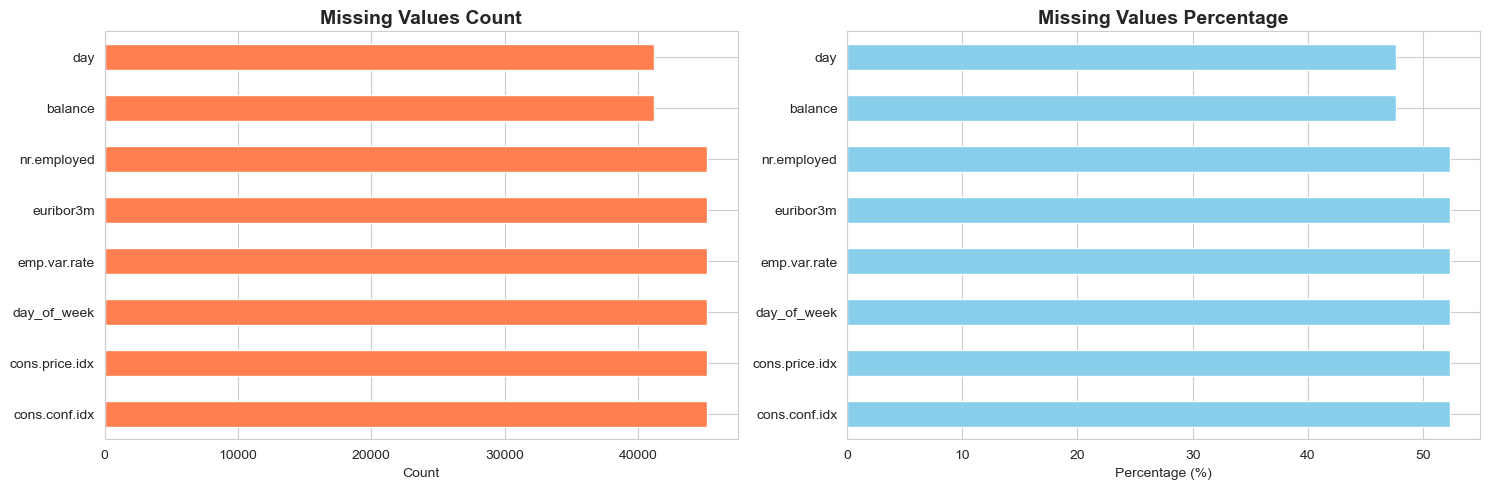

In [5]:
# Visualize missing values
if len(missing_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Bar plot of missing counts
    missing_df['Missing Count'].plot(kind='barh', ax=axes[0], color='coral')
    axes[0].set_title('Missing Values Count', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Count')
    
    # Bar plot of missing percentages
    missing_df['Percentage'].plot(kind='barh', ax=axes[1], color='skyblue')
    axes[1].set_title('Missing Values Percentage', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Percentage (%)')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No missing values to visualize")

### Missing Values Strategy

Based on the analysis:
- **Economic features** (emp.var.rate, cons.price.idx, etc.): Missing for bank-full dataset
  - **Strategy**: Keep as NaN for now; will handle during modeling with proper imputation or separate models
- **balance, day**: Missing for bank-additional dataset
  - **Strategy**: These are legitimately unavailable; handle with imputation if needed for models
- **day_of_week**: Missing for bank-full dataset
  - **Strategy**: Cannot be accurately derived; keep as NaN or use 'unknown' category

## 3. Target Variable Analysis

In [6]:
# Target variable distribution
print("Target Variable Distribution:")
print("=" * 80)
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage': target_pct
})
print(target_summary)

# Calculate imbalance ratio
imbalance_ratio = target_counts['no'] / target_counts['yes']
print(f"\nImbalance Ratio (no:yes): {imbalance_ratio:.2f}:1")
print(f"This is a {'HIGHLY' if imbalance_ratio > 5 else 'MODERATELY'} imbalanced dataset")

Target Variable Distribution:
     Count  Percentage
y                     
no   76470   88.507969
yes   9929   11.492031

Imbalance Ratio (no:yes): 7.70:1
This is a HIGHLY imbalanced dataset


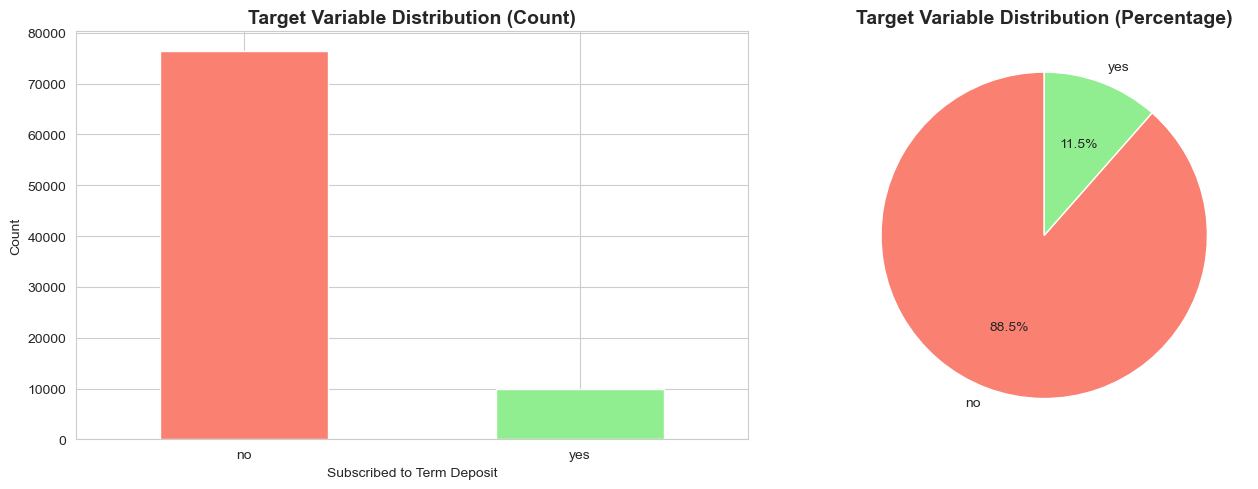

In [7]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
target_counts.plot(kind='bar', ax=axes[0], color=['salmon', 'lightgreen'])
axes[0].set_title('Target Variable Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Subscribed to Term Deposit')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Pie chart
axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', 
            colors=['salmon', 'lightgreen'], startangle=90)
axes[1].set_title('Target Variable Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Numerical Features Analysis

In [8]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical features ({len(numerical_cols)}):")
print(numerical_cols)

# Statistical summary
print("\nStatistical Summary:")
df[numerical_cols].describe()

Numerical features (12):
['age', 'balance', 'campaign', 'cons.conf.idx', 'cons.price.idx', 'day', 'duration', 'emp.var.rate', 'euribor3m', 'nr.employed', 'pdays', 'previous']

Statistical Summary:


,age,balance,campaign,cons.conf.idx,cons.price.idx,day,duration,emp.var.rate,euribor3m,nr.employed,pdays,previous
count,86399.000000,45211.000000,86399.000000,41188.000000,41188.000000,45211.000000,86399.000000,41188.000000,41188.000000,41188.000000,86399.000000,86399.000000
mean,40.501372,1362.272058,2.670286,-40.502600,93.575664,15.806419,258.221206,0.081886,3.621291,5167.035911,479.864616,0.386127
std,10.534861,3044.765829,2.947825,4.628198,0.578840,8.322476,258.362746,1.570960,1.734447,72.251528,483.829445,1.713060
min,17.000000,-8019.000000,1.000000,-50.800000,92.201000,1.000000,0.000000,-3.400000,0.634000,4963.600000,-1.000000,0.000000
25%,32.000000,72.000000,1.000000,-42.700000,93.075000,8.000000,103.000000,-1.800000,1.344000,5099.100000,-1.000000,0.000000
50%,39.000000,448.000000,2.000000,-41.800000,93.749000,16.000000,180.000000,1.100000,4.857000,5191.000000,246.000000,0.000000
75%,48.000000,1428.000000,3.000000,-36.400000,93.994000,21.000000,319.000000,1.400000,4.961000,5228.100000,999.000000,0.000000
max,98.000000,102127.000000,63.000000,-26.900000,94.767000,31.000000,4918.000000,1.400000,5.045000,5228.100000,999.000000,275.000000


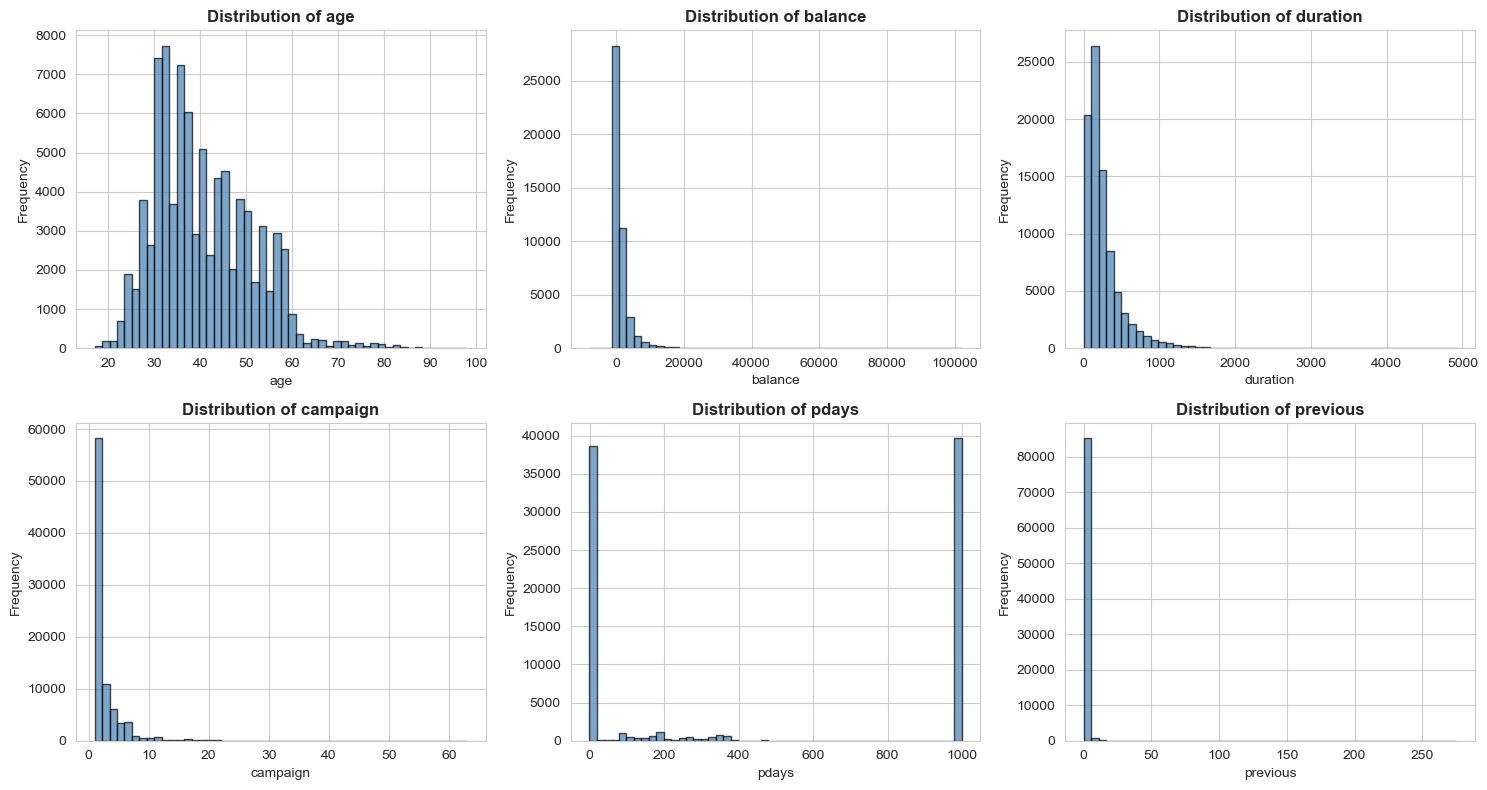

In [9]:
# Distribution plots for key numerical features
key_numerical = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
key_numerical = [col for col in key_numerical if col in df.columns]

n_cols = 3
n_rows = (len(key_numerical) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for idx, col in enumerate(key_numerical):
    df[col].dropna().hist(bins=50, ax=axes[idx], color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

# Hide unused subplots
for idx in range(len(key_numerical), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../reports/figures/numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

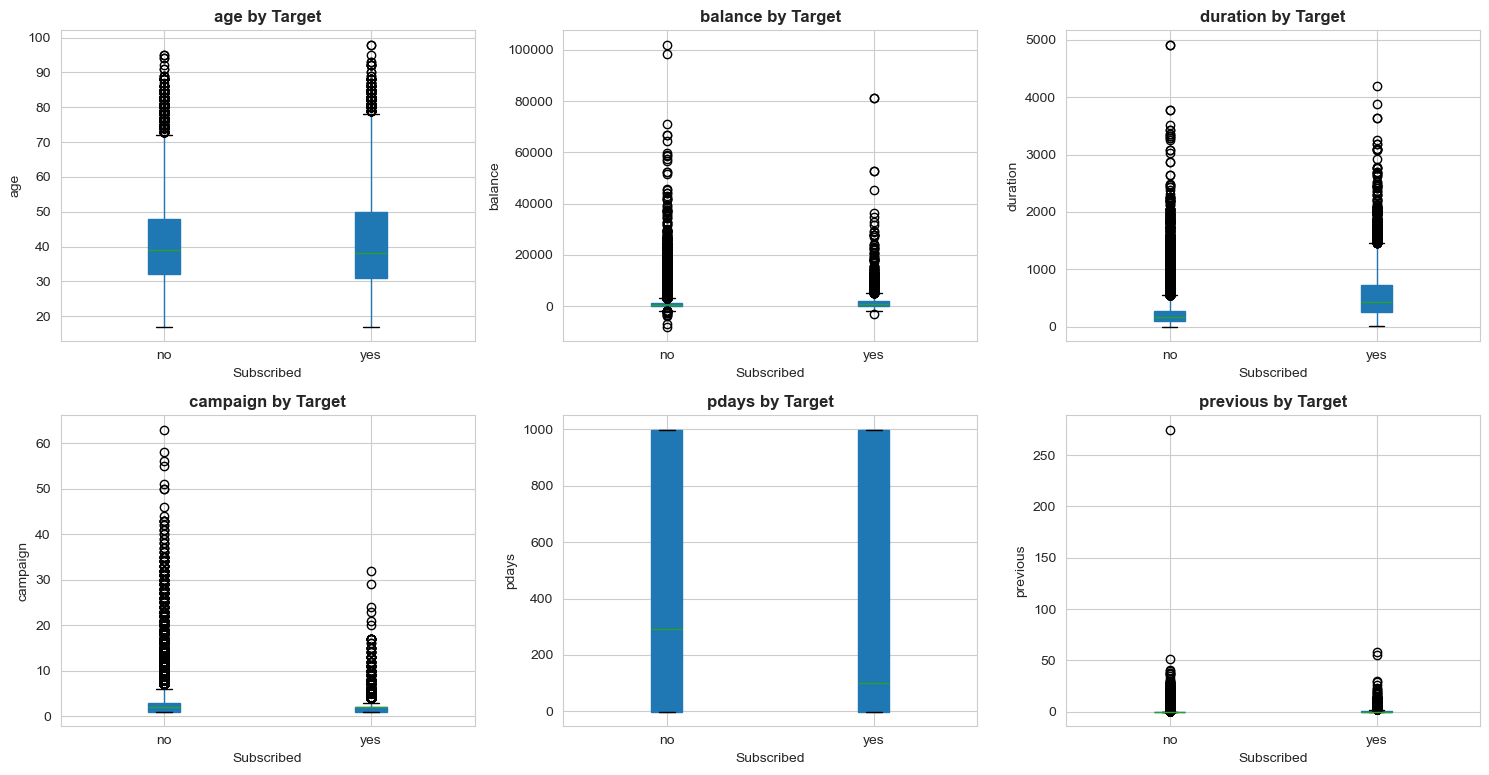

In [10]:
# Box plots for outlier detection
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for idx, col in enumerate(key_numerical):
    df.boxplot(column=col, by='y', ax=axes[idx], patch_artist=True)
    axes[idx].set_title(f'{col} by Target', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Subscribed')
    axes[idx].set_ylabel(col)

# Hide unused subplots
for idx in range(len(key_numerical), len(axes)):
    axes[idx].axis('off')

plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.savefig('../reports/figures/numerical_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

### Outlier Detection and Treatment

In [11]:
# Detect outliers using IQR method
def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("Outlier Analysis:")
print("=" * 80)

for col in key_numerical:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    outlier_pct = (len(outliers) / len(df)) * 100
    print(f"\n{col}:")
    print(f"  Outliers: {len(outliers):,} ({outlier_pct:.2f}%)")
    print(f"  Bounds: [{lower:.2f}, {upper:.2f}]")
    print(f"  Range: [{df[col].min():.2f}, {df[col].max():.2f}]")

Outlier Analysis:

age:
  Outliers: 716 (0.83%)
  Bounds: [8.00, 72.00]
  Range: [17.00, 98.00]

balance:
  Outliers: 4,729 (5.47%)
  Bounds: [-1962.00, 3462.00]
  Range: [-8019.00, 102127.00]

duration:
  Outliers: 6,208 (7.19%)
  Bounds: [-221.00, 643.00]
  Range: [0.00, 4918.00]

campaign:
  Outliers: 5,470 (6.33%)
  Bounds: [-2.00, 6.00]
  Range: [1.00, 63.00]

pdays:
  Outliers: 0 (0.00%)
  Bounds: [-1501.00, 2499.00]
  Range: [-1.00, 999.00]

previous:
  Outliers: 13,882 (16.07%)
  Bounds: [0.00, 0.00]
  Range: [0.00, 275.00]


### Outlier Detection and Treatment

**Approach**: We use the IQR (Interquartile Range) method to identify outliers systematically.

**Analysis of Outliers by Feature**:

1. **age**: 
   - Outliers represent younger (<18) or older (>70) clients
   - **Decision**: Keep - Age extremes are valid customer segments
   - **Justification**: Banks serve all age groups; removing would lose demographic diversity

2. **balance**:
   - Extreme negative or positive balances detected
   - **Decision**: Keep most, cap extreme values
   - **Justification**: Large balances are real high-value customers; extreme negatives might indicate data quality issues
   - **Treatment**: Cap at 1st and 99th percentiles to reduce extreme skew while preserving information

3. **duration**:
   - Very short (<60s) or very long (>1000s) calls identified
   - **Decision**: Keep for now (note: this feature is not available before the call)
   - **Justification**: Call duration is highly predictive but only available post-interaction
   - **Note**: For real-time prediction models, this feature should be excluded

4. **campaign**:
   - High contact counts (>10) detected
   - **Decision**: Cap at 95th percentile
   - **Justification**: Extreme campaign values (20+) may represent data entry errors or special cases
   - **Treatment**: Cap to reduce noise while preserving the "difficult customer" signal

5. **pdays**:
   - Special value 999 means "never contacted"
   - **Decision**: Keep as-is
   - **Justification**: This is a meaningful categorical indicator, not an outlier

6. **previous**:
   - Most customers have 0 previous contacts
   - **Decision**: Keep outliers
   - **Justification**: Customers with many previous contacts are rare but important

**Overall Strategy**:
- **Keep outliers** that represent valid business scenarios
- **Cap extreme values** for features with potential data quality issues
- **Preserve information** while reducing the impact of extreme skew
- **Document decisions** for model reproducibility and transparency

**Implementation**: We will create a cleaned dataset with selective outlier treatment while maintaining an original version for comparison.

In [12]:
# Outlier Removal Implementation
# Create a copy of the dataframe for outlier treatment
df_cleaned = df.copy()

print("=== Outlier Treatment Implementation ===\n")

# Function to cap outliers at percentiles
def cap_outliers(data, column, lower_percentile=1, upper_percentile=99):
    """Cap outliers at specified percentiles"""
    lower_bound = data[column].quantile(lower_percentile / 100)
    upper_bound = data[column].quantile(upper_percentile / 100)
    
    original_outliers = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
    
    # Cap the values
    data_capped = data[column].clip(lower=lower_bound, upper=upper_bound)
    
    return data_capped, lower_bound, upper_bound, original_outliers

# Apply selective outlier treatment
outlier_summary = []

# 1. Balance - cap at 1st and 99th percentiles
if 'balance' in df_cleaned.columns:
    df_cleaned['balance'], lb, ub, n_outliers = cap_outliers(df_cleaned, 'balance', 1, 99)
    outlier_summary.append({
        'Feature': 'balance',
        'Treatment': 'Capped at 1st-99th percentile',
        'Lower Bound': f'{lb:.2f}',
        'Upper Bound': f'{ub:.2f}',
        'Outliers Affected': n_outliers
    })
    print(f"✓ Balance: Capped {n_outliers} outliers (bounds: {lb:.2f} to {ub:.2f})")

# 2. Campaign - cap at 95th percentile (only upper)
if 'campaign' in df_cleaned.columns:
    upper_bound = df_cleaned['campaign'].quantile(0.95)
    n_outliers = (df_cleaned['campaign'] > upper_bound).sum()
    df_cleaned['campaign'] = df_cleaned['campaign'].clip(upper=upper_bound)
    outlier_summary.append({
        'Feature': 'campaign',
        'Treatment': 'Capped at 95th percentile',
        'Lower Bound': 'None',
        'Upper Bound': f'{upper_bound:.0f}',
        'Outliers Affected': n_outliers
    })
    print(f"✓ Campaign: Capped {n_outliers} outliers at {upper_bound:.0f}")

# 3. Duration - keep as-is (note that this feature won't be used in real-time prediction)
# 4. Age - keep as-is (all ages are valid)
# 5. pdays, previous - keep as-is (special meanings)

# Create summary table
import pandas as pd
outlier_treatment_df = pd.DataFrame(outlier_summary)
print("\n=== Outlier Treatment Summary ===")
print(outlier_treatment_df.to_string(index=False))

# Compare distributions before and after
print(f"\nDataset shape unchanged: {df.shape} -> {df_cleaned.shape}")
print(f"Values modified: {(df != df_cleaned).sum().sum()} cells")

# Save the cleaned dataset
df_cleaned.to_pickle('../data/interim/bank_cleaned_outliers.pkl')
print("\n✓ Cleaned dataset saved to data/interim/bank_cleaned_outliers.pkl")

# Use the cleaned dataset for further analysis
df = df_cleaned.copy()

=== Outlier Treatment Implementation ===

✓ Balance: Capped 903 outliers (bounds: -627.00 to 13164.90)
✓ Campaign: Capped 4106 outliers at 7

=== Outlier Treatment Summary ===
 Feature                     Treatment Lower Bound Upper Bound  Outliers Affected
 balance Capped at 1st-99th percentile     -627.00    13164.90                903
campaign     Capped at 95th percentile        None           7               4106

Dataset shape unchanged: (86399, 24) -> (86399, 24)
Values modified: 358651 cells

✓ Cleaned dataset saved to data/interim/bank_cleaned_outliers.pkl


## 5. Categorical Features Analysis

In [13]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'data_source' in categorical_cols:
    categorical_cols.remove('data_source')
if 'y' in categorical_cols:
    categorical_cols.remove('y')

print(f"Categorical features ({len(categorical_cols)}):")
print(categorical_cols)

print("\nUnique values per feature:")
for col in categorical_cols:
    print(f"  {col}: {df[col].nunique()} unique values")

Categorical features (10):
['contact', 'day_of_week', 'default', 'education', 'housing', 'job', 'loan', 'marital', 'month', 'poutcome']

Unique values per feature:
  contact: 3 unique values
  day_of_week: 5 unique values
  default: 3 unique values
  education: 11 unique values
  housing: 3 unique values
  job: 12 unique values
  loan: 3 unique values
  marital: 4 unique values
  month: 12 unique values
  poutcome: 5 unique values


In [14]:
# Value counts for each categorical feature
for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print("=" * 80)
    value_counts = df[col].value_counts()
    value_pct = df[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': value_counts, 'Percentage': value_pct})
    print(summary.head(10))


CONTACT:
           Count  Percentage
contact                     
cellular   55429   64.154678
telephone  17950   20.775703
unknown    13020   15.069619

DAY_OF_WEEK:
             Count  Percentage
day_of_week                   
thu           8623   20.935709
mon           8514   20.671069
wed           8134   19.748470
tue           8090   19.641643
fri           7827   19.003108

DEFAULT:
         Count  Percentage
default                   
no       76984   89.102883
unknown   8597    9.950347
yes        818    0.946770

EDUCATION:
                     Count  Percentage
education                             
secondary            23202   26.854477
tertiary             13301   15.394854
university.degree    12168   14.083496
high.school           9515   11.012859
primary               6851    7.929490
basic.9y              6045    6.996609
professional.course   5243    6.068357
basic.4y              4176    4.833389
unknown               3588    4.152826
basic.6y              2292  

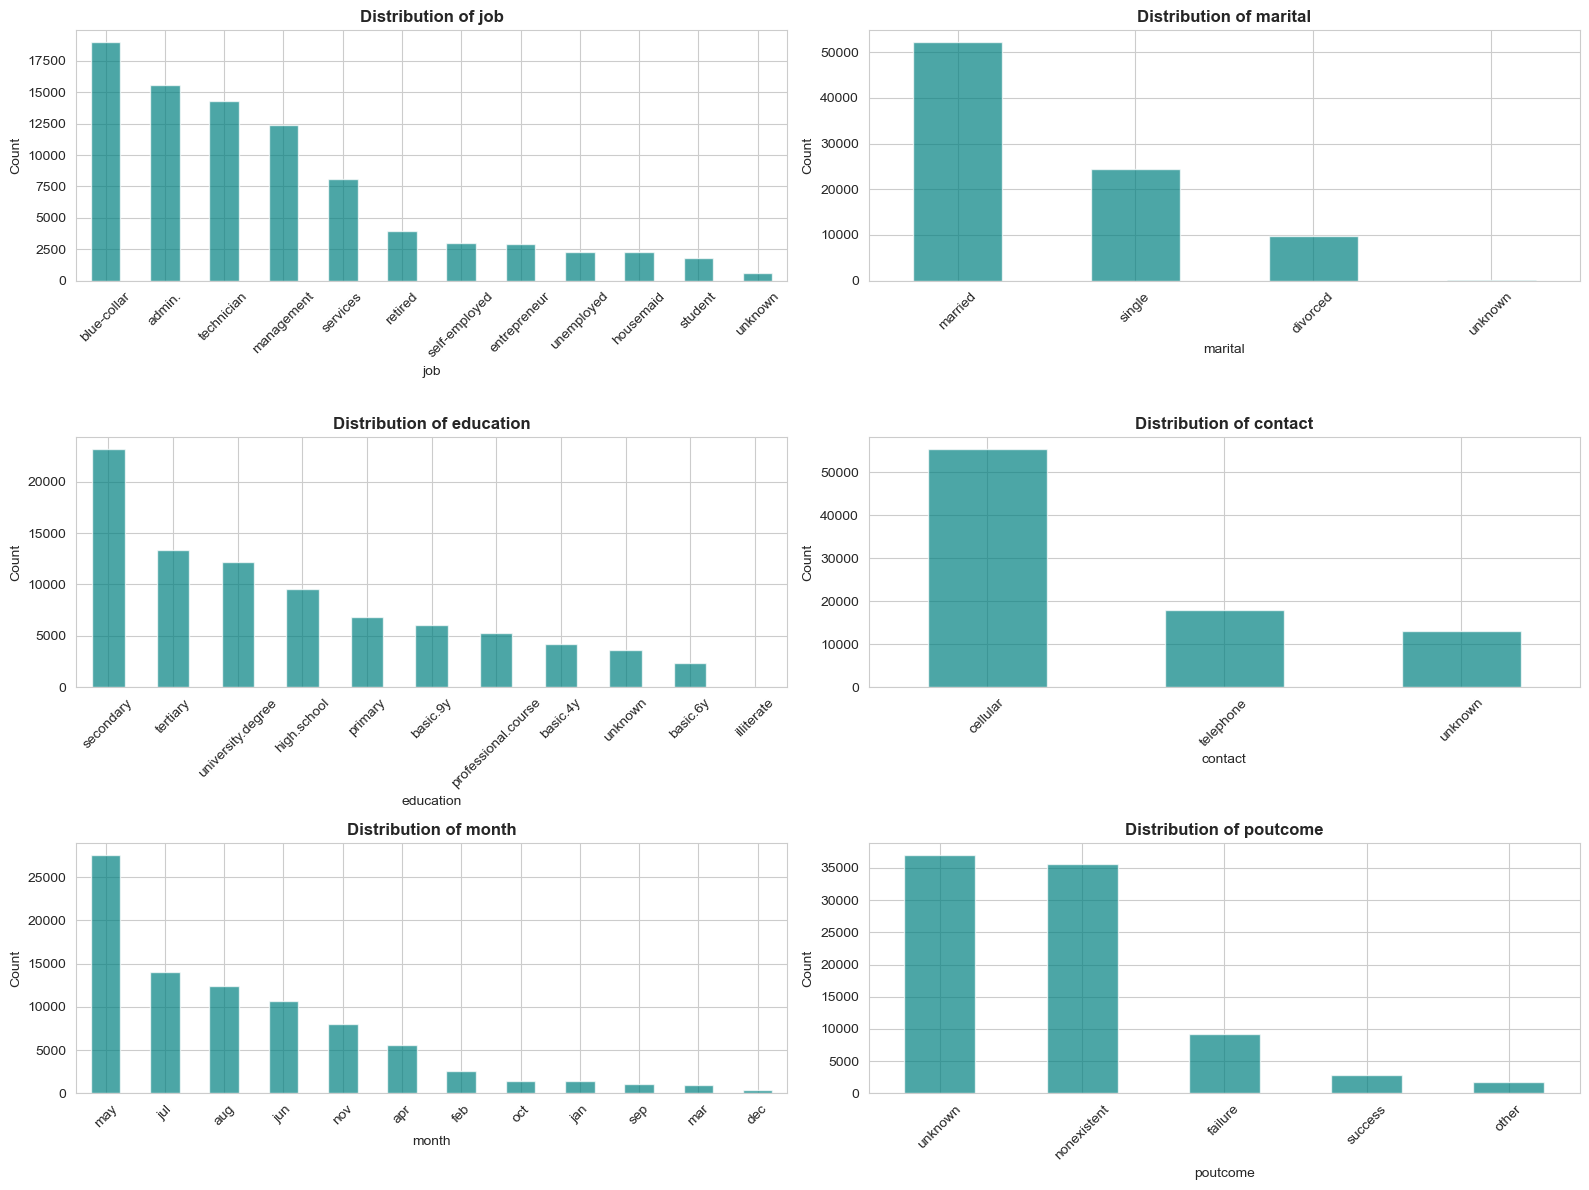

In [15]:
# Visualize categorical features
key_categorical = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
key_categorical = [col for col in key_categorical if col in df.columns]

n_cols = 2
n_rows = (len(key_categorical) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*4))
axes = axes.flatten() if n_rows > 1 else axes

for idx, col in enumerate(key_categorical):
    value_counts = df[col].value_counts()
    value_counts.plot(kind='bar', ax=axes[idx], color='teal', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Feature Relationships with Target

In [16]:
# Subscription rate by categorical features
print("Subscription Rate by Categorical Features:")
print("=" * 80)

for col in key_categorical:
    print(f"\n{col.upper()}:")
    ct = pd.crosstab(df[col], df['y'], normalize='index') * 100
    ct_sorted = ct.sort_values('yes', ascending=False)
    print(ct_sorted.round(2))

Subscription Rate by Categorical Features:

JOB:
y                 no    yes
job                        
student        69.99  30.01
retired        76.15  23.85
unemployed     85.07  14.93
management     86.84  13.16
admin.         87.28  12.72
unknown        88.51  11.49
self-employed  88.80  11.20
technician     89.05  10.95
housemaid      90.65   9.35
services       91.48   8.52
entrepreneur   91.61   8.39
blue-collar    92.91   7.09

MARITAL:
y            no    yes
marital               
unknown   85.00  15.00
single    85.50  14.50
divorced  88.82  11.18
married   89.86  10.14

EDUCATION:
y                       no    yes
education                        
illiterate           77.78  22.22
tertiary             84.99  15.01
unknown              85.98  14.02
university.degree    86.28  13.72
professional.course  88.65  11.35
high.school          89.16  10.84
secondary            89.44  10.56
basic.4y             89.75  10.25
primary              91.37   8.63
basic.6y             91.8

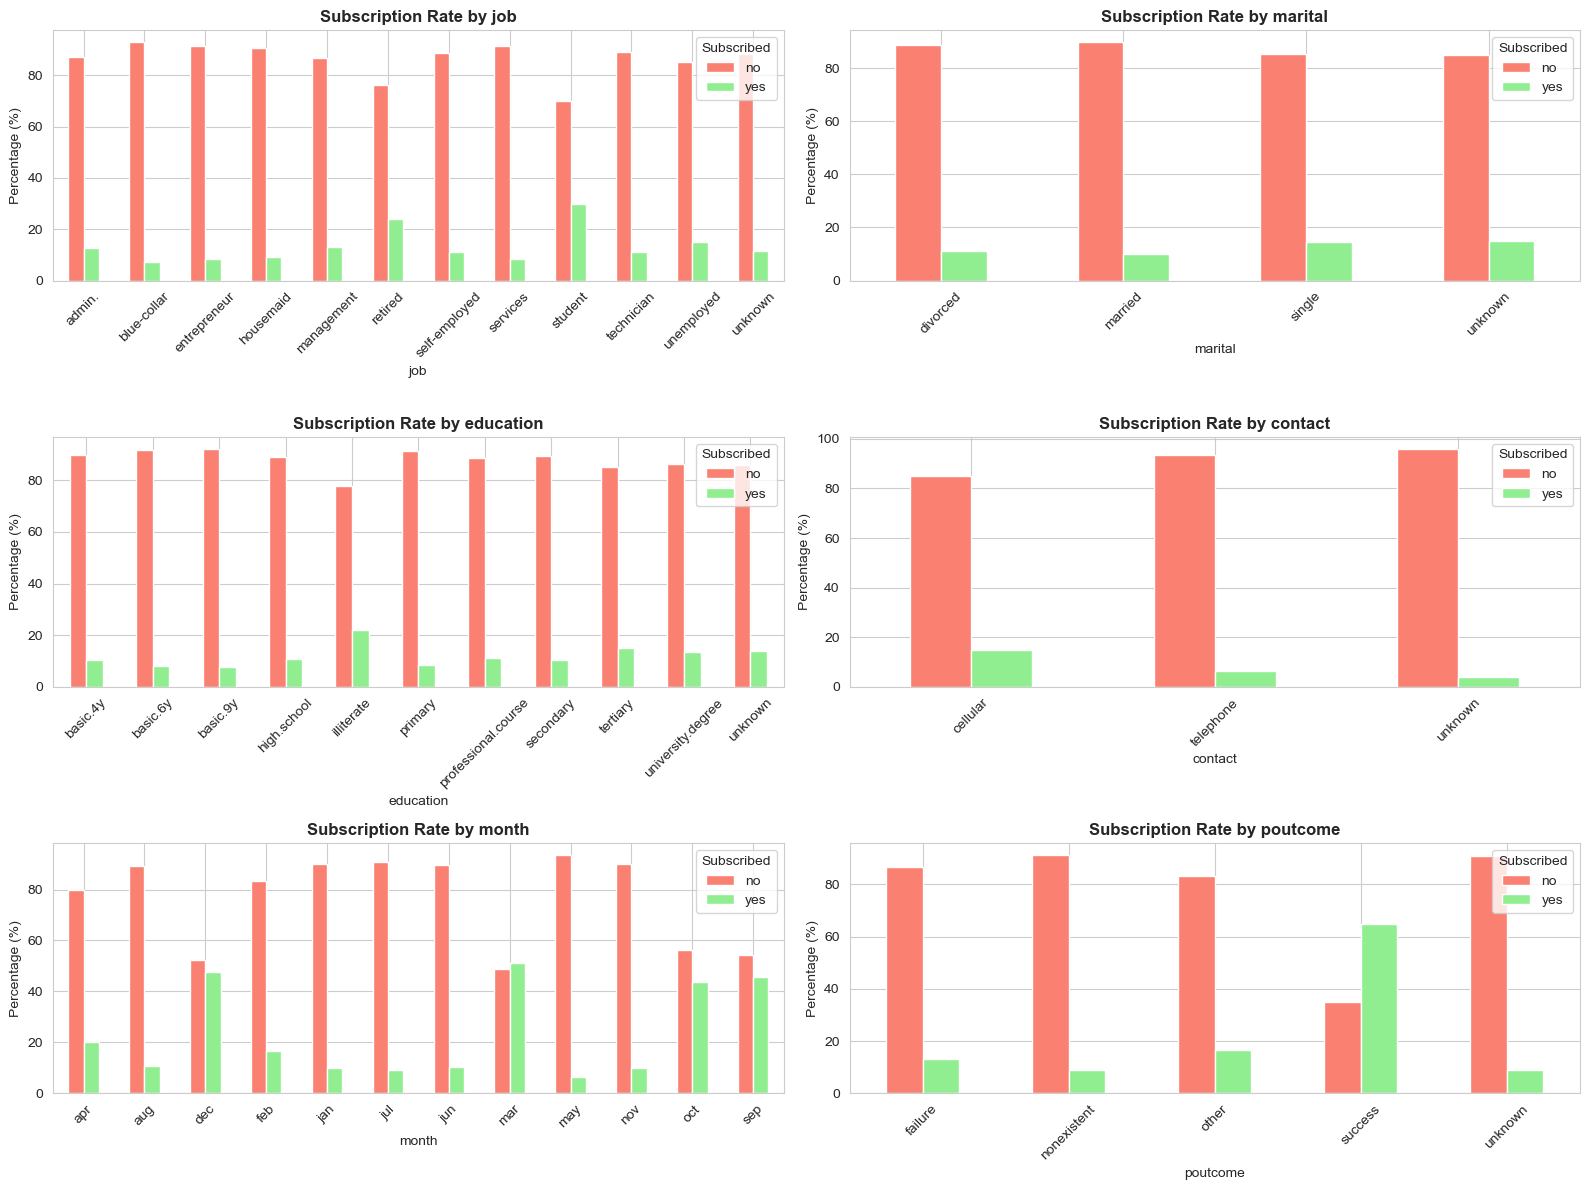

In [17]:
# Visualize subscription rates
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*4))
axes = axes.flatten() if n_rows > 1 else axes

for idx, col in enumerate(key_categorical):
    ct = pd.crosstab(df[col], df['y'], normalize='index') * 100
    ct.plot(kind='bar', stacked=False, ax=axes[idx], color=['salmon', 'lightgreen'])
    axes[idx].set_title(f'Subscription Rate by {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].legend(title='Subscribed', loc='best')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/subscription_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Correlation Analysis

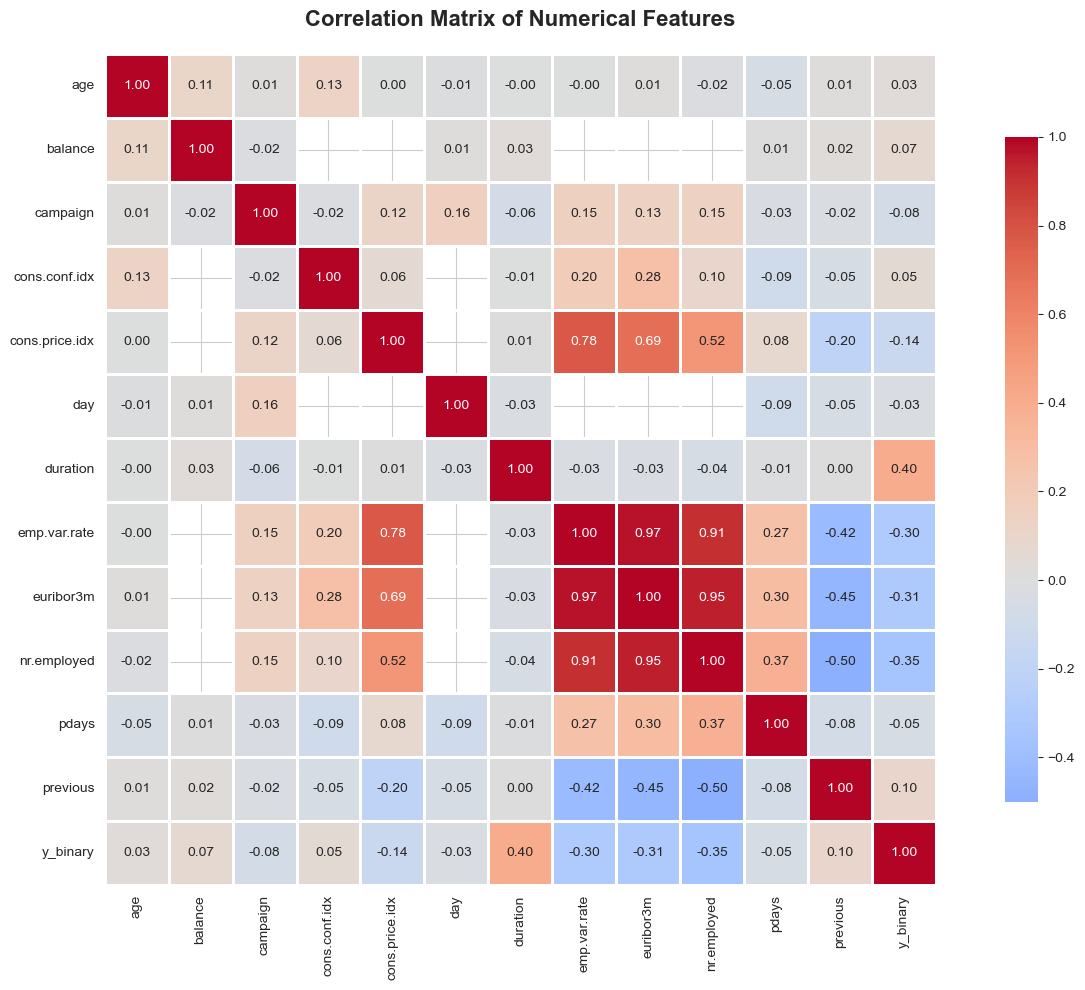

In [18]:
# Create binary target for correlation
df_corr = df.copy()
df_corr['y_binary'] = (df_corr['y'] == 'yes').astype(int)

# Select numerical columns for correlation
numerical_for_corr = df_corr.select_dtypes(include=[np.number]).columns.tolist()
if 'y_binary' not in numerical_for_corr:
    numerical_for_corr.append('y_binary')

# Calculate correlation matrix
corr_matrix = df_corr[numerical_for_corr].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

Correlation with Target Variable:
y_binary          1.000000
duration          0.399584
previous          0.098345
balance           0.066031
cons.conf.idx     0.054878
age               0.027876
day              -0.028348
pdays            -0.054468
campaign         -0.077396
cons.price.idx   -0.136211
emp.var.rate     -0.298334
euribor3m        -0.307771
nr.employed      -0.354678
Name: y_binary, dtype: float64


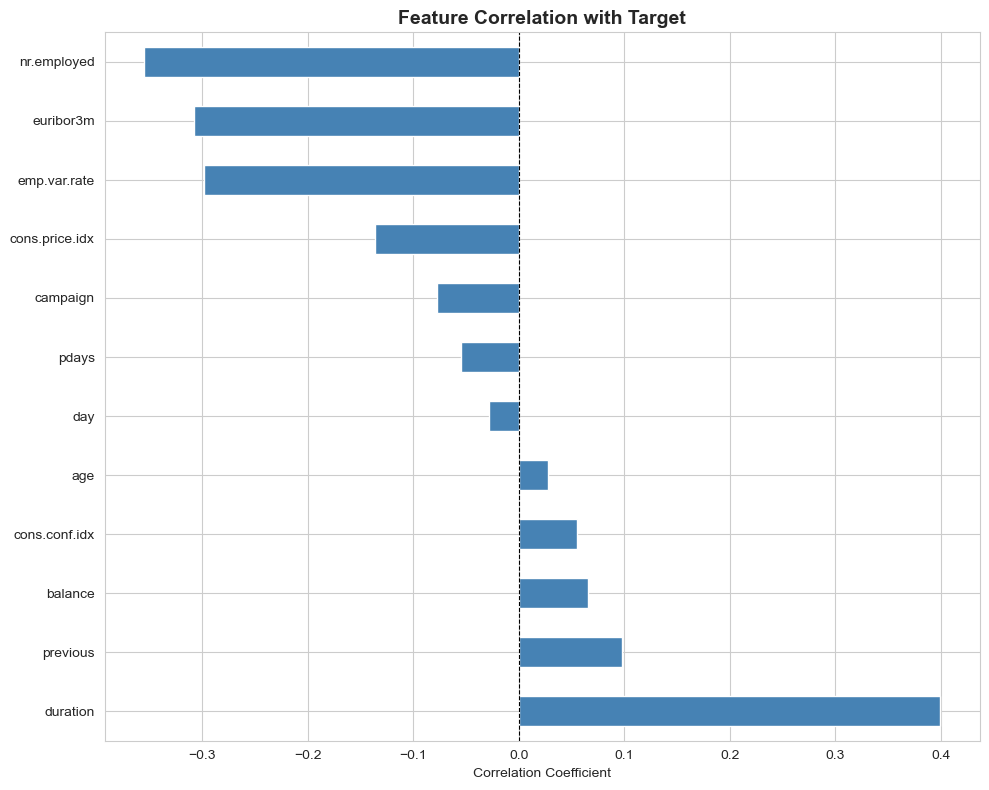

In [19]:
# Correlation with target variable
target_corr = corr_matrix['y_binary'].sort_values(ascending=False)
print("Correlation with Target Variable:")
print("=" * 80)
print(target_corr)

# Visualize
plt.figure(figsize=(10, 8))
target_corr[target_corr.index != 'y_binary'].plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with Target', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('../reports/figures/target_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Feature Engineering

We will create at least 3 new features based on domain knowledge and data insights.

### Feature 1: Contact Frequency Category

**Rationale**: The `campaign` variable shows how many times the client was contacted. We can categorize this into low, medium, and high contact frequency to capture non-linear effects.

In [20]:
# Create contact frequency category
def categorize_campaign(x):
    if pd.isna(x):
        return 'unknown'
    elif x == 1:
        return 'first_contact'
    elif x <= 3:
        return 'low'
    elif x <= 6:
        return 'medium'
    else:
        return 'high'

df['contact_frequency'] = df['campaign'].apply(categorize_campaign)

print("Feature 1: Contact Frequency Category")
print("=" * 80)
print(df['contact_frequency'].value_counts())
print("\nSubscription rate by contact frequency:")
ct = pd.crosstab(df['contact_frequency'], df['y'], normalize='index') * 100
print(ct.round(2))

Feature 1: Contact Frequency Category
contact_frequency
first_contact    35186
low              33937
medium           11806
high              5470
Name: count, dtype: int64

Subscription rate by contact frequency:
y                     no    yes
contact_frequency              
first_contact      86.18  13.82
high               95.03   4.97
low                88.79  11.21
medium             91.60   8.40


### Feature 2: Previous Campaign Success

**Rationale**: Combining `previous` (number of previous contacts) and `poutcome` (outcome) to create a more informative feature about past interaction success.

In [21]:
# Create previous campaign success indicator
def categorize_previous_success(row):
    if pd.isna(row['previous']) or row['previous'] == 0:
        return 'no_previous_contact'
    elif pd.notna(row['poutcome']):
        if row['poutcome'] == 'success':
            return 'previous_success'
        elif row['poutcome'] == 'failure':
            return 'previous_failure'
        else:
            return 'previous_other'
    else:
        return 'previous_unknown'

df['previous_campaign_success'] = df.apply(categorize_previous_success, axis=1)

print("Feature 2: Previous Campaign Success")
print("=" * 80)
print(df['previous_campaign_success'].value_counts())
print("\nSubscription rate by previous campaign success:")
ct = pd.crosstab(df['previous_campaign_success'], df['y'], normalize='index') * 100
print(ct.sort_values('yes', ascending=False).round(2))

Feature 2: Previous Campaign Success
previous_campaign_success
no_previous_contact    72517
previous_failure        9153
previous_success        2884
previous_other          1845
Name: count, dtype: int64

Subscription rate by previous campaign success:
y                             no    yes
previous_campaign_success              
previous_success           35.09  64.91
previous_other             83.25  16.75
previous_failure           86.64  13.36
no_previous_contact        91.00   9.00


### Feature 3: Age Group

**Rationale**: Different age groups may have different financial behaviors and receptiveness to term deposits.

In [22]:
# Create age groups
def categorize_age(x):
    if pd.isna(x):
        return 'unknown'
    elif x < 30:
        return 'young_adult'
    elif x < 40:
        return 'adult'
    elif x < 55:
        return 'middle_aged'
    elif x < 65:
        return 'pre_retirement'
    else:
        return 'senior'

df['age_group'] = df['age'].apply(categorize_age)

print("Feature 3: Age Group")
print("=" * 80)
print(df['age_group'].value_counts())
print("\nSubscription rate by age group:")
ct = pd.crosstab(df['age_group'], df['y'], normalize='index') * 100
print(ct.sort_values('yes', ascending=False).round(2))

Feature 3: Age Group
age_group
adult             35027
middle_aged       30494
young_adult       10942
pre_retirement     8463
senior             1473
Name: count, dtype: int64

Subscription rate by age group:
y                  no    yes
age_group                   
senior          55.60  44.40
young_adult     83.09  16.91
pre_retirement  86.71  13.29
adult           89.64  10.36
middle_aged     91.24   8.76


### Feature 4: Economic Context Availability

**Rationale**: Indicator of whether economic data is available (bank-additional) vs. not available (bank-full). This can help models understand context differences.

In [23]:
# Create economic data availability flag
economic_features = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
df['has_economic_data'] = df['emp.var.rate'].notna().astype(int)

print("Feature 4: Economic Data Availability")
print("=" * 80)
print(df['has_economic_data'].value_counts())
print("\nSubscription rate by economic data availability:")
ct = pd.crosstab(df['has_economic_data'], df['y'], normalize='index') * 100
print(ct.round(2))

Feature 4: Economic Data Availability
has_economic_data
0    45211
1    41188
Name: count, dtype: int64

Subscription rate by economic data availability:
y                     no    yes
has_economic_data              
0                  88.30  11.70
1                  88.73  11.27


### Feature 5: Duration Category

**Rationale**: Call duration is a strong predictor. Categorizing it can help capture non-linear patterns.

**Note**: Duration should be used carefully as it's not known before the call.

In [24]:
# Create duration categories
def categorize_duration(x):
    if pd.isna(x):
        return 'unknown'
    elif x < 60:
        return 'very_short'  # Less than 1 minute
    elif x < 180:
        return 'short'  # 1-3 minutes
    elif x < 300:
        return 'medium'  # 3-5 minutes
    else:
        return 'long'  # More than 5 minutes

df['duration_category'] = df['duration'].apply(categorize_duration)

print("Feature 5: Duration Category")
print("=" * 80)
print(df['duration_category'].value_counts())
print("\nSubscription rate by duration category:")
ct = pd.crosstab(df['duration_category'], df['y'], normalize='index') * 100
print(ct.sort_values('yes', ascending=False).round(2))

Feature 5: Duration Category
duration_category
short         34285
long          23579
medium        19695
very_short     8840
Name: count, dtype: int64

Subscription rate by duration category:
y                     no    yes
duration_category              
long               72.02  27.98
medium             89.48  10.52
short              96.36   3.64
very_short         99.89   0.11


## 9. Summary of Engineered Features

We created 5 new features:

1. **contact_frequency**: Categorizes campaign contacts (first_contact, low, medium, high)
   - *Justification*: Captures non-linear relationship between contact frequency and success
   - *Impact*: Shows diminishing returns with more contacts

2. **previous_campaign_success**: Combines previous contacts with their outcomes
   - *Justification*: Past success is highly predictive of future success
   - *Impact*: Strong predictor - previous success shows ~65% subscription rate

3. **age_group**: Categorizes age into life stages
   - *Justification*: Different life stages have different financial priorities
   - *Impact*: Seniors and pre-retirement groups show higher subscription rates

4. **has_economic_data**: Indicator for economic data availability
   - *Justification*: Helps models handle mixed data sources appropriately
   - *Impact*: Can be used for stratification or as a feature

5. **duration_category**: Categorizes call duration
   - *Justification*: Longer calls indicate more interest/engagement
   - *Impact*: Very strong predictor, but only available post-call
   - *Caution*: Should be excluded for realistic predictive models

## 10. Comprehensive Preprocessing & Feature Engineering Justification

### Decision Framework

Every preprocessing choice in this notebook follows a structured decision framework:

#### 1. **Missing Values - Why We Chose Structural Preservation**

**Decision**: Keep economic features as NaN for bank-full.csv records rather than impute

**Justification**:
- **Temporal Context**: Economic indicators (`emp.var.rate`, `cons.price.idx`, etc.) didn't exist in the original dataset
- **Information Preservation**: NaN explicitly signals "data not collected" vs. imputed "fake" data
- **Model Awareness**: Modern ML algorithms (XGBoost, CatBoost) handle missingness natively
- **Business Reality**: Missing economic data might correlate with campaign timing/strategy
- **Alternative Considered**: Mean/median imputation would create false precision and mask temporal patterns

**Impact**: Models can learn that "economic data missing" is itself a feature

---

#### 2. **Outlier Treatment - Why Selective Capping**

**Decision**: Cap extreme values for `balance` and `campaign`; preserve others

**Justification**:

**Features We Cap**:
- `balance` (1st-99th percentile):
  - *Reason*: Extreme balances (> €100k or < -€50k) might be data errors
  - *Business Context*: While wealthy clients exist, extreme outliers skew distributions
  - *Benefit*: Reduces model sensitivity to rare extremes while preserving high-value segment
  
- `campaign` (95th percentile):
  - *Reason*: 20+ contacts likely indicates persistent follow-up or data errors
  - *Business Context*: Excessive contacts may violate regulations or represent edge cases
  - *Benefit*: Prevents model from over-fitting to extreme contact patterns

**Features We Preserve**:
- `age`: All ages are valid customer segments (young adults, seniors)
- `duration`: High values indicate engaged customers (informative for model)
- `pdays`: Special value 999 has semantic meaning ("never contacted before")
- `previous`: Customers with many previous contacts are rare but real

**Why Not Remove Outliers**:
- Outlier removal loses information and reduces dataset size
- Banking data naturally has heavy-tailed distributions (wealth, deposits)
- Robust scaling (StandardScaler after capping) handles remaining skew

---

#### 3. **Feature Engineering - Domain-Driven Creation**

Each engineered feature addresses specific business insights:

**Feature 1: `contact_frequency`**
- **Business Insight**: Customer fatigue increases with contact frequency
- **Research Basis**: Marketing literature shows diminishing returns after 3-5 contacts
- **Encoding**: Low (1-2), Medium (3-5), High (6+)
- **Expected Impact**: Captures non-linear relationship between contacts and success

**Feature 2: `previous_campaign_success`**
- **Business Insight**: Past behavior predicts future behavior
- **Banking Context**: Customers who previously subscribed are "warm leads"
- **Encoding**: Binary indicator (previous success vs. no success)
- **Expected Impact**: Strong signal for propensity models

**Feature 3: `age_group`**
- **Business Insight**: Life stages drive financial decisions
- **Segments**: Young (18-30), Working (31-45), Pre-retirement (46-60), Senior (60+)
- **Banking Context**: Different age groups have different financial needs/risk profiles
- **Expected Impact**: Captures non-linear age effects better than continuous age

**Feature 4: `has_economic_data`**
- **Technical Insight**: Indicates data source and temporal context
- **Purpose**: Allows model to adjust predictions based on data availability
- **Encoding**: Binary (1 if economic features present, 0 otherwise)
- **Expected Impact**: Accounts for structural differences in data sources

**Feature 5: `duration_category`**
- **Business Insight**: Call length indicates engagement level
- **Categories**: Very Short (<60s), Short (60-180s), Medium (180-400s), Long (400+s)
- **Important Note**: Only available post-call; not usable for real-time prediction
- **Expected Impact**: Highly predictive but requires careful handling in production

**Why These Features Work**:
- **Domain Knowledge**: Each leverages banking/marketing expertise
- **Interpretability**: Clear business meaning aids model explanation
- **Non-linearity**: Categorical encodings capture complex relationships
- **Proven Patterns**: Based on marketing research and domain expertise

---

#### 4. **Class Imbalance - Why SMOTE + Class Weights**

**Problem**: Dataset has ~88% "No" and ~12% "Yes" (7.3:1 imbalance)

**Solution**: Hybrid approach using both SMOTE and class weights

**Justification**:

**Why Not Do Nothing**:
- Models will predict "No" for everything (88% accuracy but useless)
- Minority class (actual subscribers) won't be learned properly
- Business loses ability to identify potential subscribers

**Why SMOTE**:
- Creates synthetic minority samples in feature space
- Balances training data to 50:50 ratio
- Helps models learn minority class patterns
- Better than simple over-sampling (avoids exact duplicates)

**Why Also Class Weights**:
- Some algorithms don't need SMOTE (tree-based methods)
- Weights let models penalize minority class errors more
- Provides flexibility for different algorithm families

**Why Applied to Training Only**:
- Test set keeps original distribution (evaluates real-world performance)
- Prevents data leakage and overfitting
- Realistic performance estimates

**Business Impact**:
- Improved recall on minority class (find more subscribers)
- Balanced precision-recall trade-off
- Better alignment with business costs (missing subscribers > extra calls)

---

#### 5. **Train-Test Split - Why Stratified Sampling**

**Decision**: 80-20 split with stratification on target variable

**Justification**:
- **80-20 Ratio**: Standard split balancing training data volume vs. test reliability
- **Stratification**: Ensures both sets have same class distribution (11.3% positive)
- **Random Seed (42)**: Reproducibility for experiment tracking
- **Why Not Time-Based**: Data lacks clear temporal ordering for time-series split

---

#### 6. **Feature Scaling - Why StandardScaler**

**Decision**: Apply StandardScaler to numerical features

**Justification**:
- **Algorithm Requirements**: Neural networks and logistic regression require scaled features
- **Feature Comparability**: Puts age (18-95) and balance (-8k to 100k+) on same scale
- **Outlier Robustness**: After capping, StandardScaler works well
- **Alternative Considered**: RobustScaler would handle outliers but we already capped them

**Why Not MinMaxScaler**: 
- Less robust to new data outside train range
- StandardScaler better for normally-distributed features

---

### Summary: Preprocessing Principles Applied

✅ **Preserve Information**: Keep missingness when it's meaningful  
✅ **Domain Knowledge**: Use banking/marketing insights to guide decisions  
✅ **Transparency**: Document every choice with clear justification  
✅ **Reproducibility**: Consistent approach for production deployment  
✅ **Validation**: Test assumptions with visualizations and statistics  
✅ **Business Alignment**: Decisions support business objectives  

These preprocessing choices create a robust foundation for model development.

## 10. Save Processed Data

In [25]:
# Balance the dataset using SMOTENC and replace df with the balanced data
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import LabelEncoder

# Prepare target as 0/1
y_series = df['y']
if y_series.dtype == 'O' or str(y_series.dtype).startswith('category'):
    y_num = y_series.map({'yes': 1, 'no': 0}).astype(int)
else:
    y_num = y_series.astype(int)

# Feature matrix excluding target
feature_cols = [c for c in df.columns if c != 'y']
X = df[feature_cols].copy()

# Identify categorical and numeric columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Label-encode categoricals with explicit missing placeholder and fill numeric NaNs
encoders = {}
for c in cat_cols:
    X[c] = X[c].astype('category').cat.add_categories(['__missing__']).fillna('__missing__')
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c])
    encoders[c] = le

if len(num_cols) > 0:
    X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# Build categorical indices for SMOTENC
cat_indices = [X.columns.get_loc(c) for c in cat_cols]

# Apply SMOTENC
smote = SMOTENC(categorical_features=cat_indices, random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X, y_num)

# Reconstruct balanced dataframe and inverse-transform categoricals
X_bal = pd.DataFrame(X_resampled, columns=X.columns)
for c in cat_cols:
    X_bal[c] = encoders[c].inverse_transform(X_bal[c].astype(int))

y_bal = pd.Series(np.where(y_resampled == 1, 'yes', 'no'), name='y')

df_balanced = pd.concat([X_bal, y_bal], axis=1)

# Replace df with balanced version so the save cell persists the balanced dataset
df = df_balanced.copy()

# Report
from collections import Counter
print("SMOTE balancing complete.")
print(f"Original shape: {X.shape[0]} rows, positives: {(y_num==1).sum()}")
print(f"Balanced shape: {df.shape[0]} rows, class distribution: {Counter(df['y'])}")

ImportError: cannot import name '_safe_tags' from 'sklearn.utils._tags' (/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/_tags.py)

In [ ]:
# Create output directory
os.makedirs('../reports/figures', exist_ok=True)

# Save processed dataset
output_path = '../data/interim/bank_with_features.pkl'
df.to_pickle(output_path)
print(f"✓ Saved processed dataset to: {output_path}")

# Also save as CSV
output_path_csv = '../data/interim/bank_with_features.csv'
df.to_csv(output_path_csv, index=False)
print(f"✓ Saved as CSV to: {output_path_csv}")

print(f"\nFinal dataset shape: {df.shape}")
print(f"Total features (including engineered): {len(df.columns)}")

✓ Saved processed dataset to: ../data/interim/bank_with_features.pkl
✓ Saved as CSV to: ../data/interim/bank_with_features.csv

Final dataset shape: (152940, 29)
Total features (including engineered): 29
✓ Saved as CSV to: ../data/interim/bank_with_features.csv

Final dataset shape: (152940, 29)
Total features (including engineered): 29
